In [7]:
import pandas as pd

df = pd.read_csv("../data/A_Z Handwritten Data.csv")

print(df.shape)

(372450, 785)


In [12]:
df.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:

df['0'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25])

In [14]:

df.rename(columns={'0':'output'}, inplace=True)

In [15]:
word_dict = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X', 24:'Y',25:'Z'}
     

In [16]:


df['output'].value_counts()

output
14    57825
18    48419
20    29008
2     23409
19    22495
15    19341
13    19010
0     13869
12    12336
11    11586
17    11566
4     11440
24    10859
22    10784
3     10134
1      8668
9      8493
7      7218
23     6272
25     6076
16     5812
6      5762
10     5603
21     4182
5      1163
8      1120
Name: count, dtype: int64

In [17]:

X = df.drop(columns=['output'])
y = df['output']

In [18]:
y = y.astype(int)

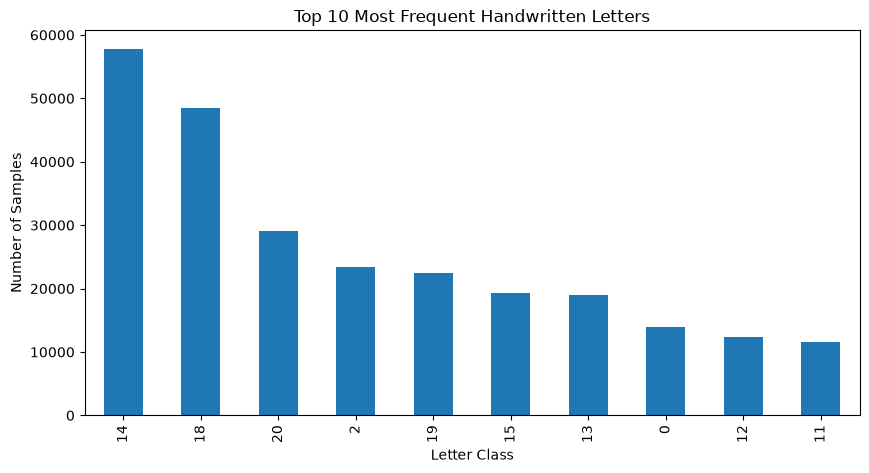

In [19]:
import matplotlib.pyplot as plt

letter_counts = df.iloc[:,0].value_counts()

plt.figure(figsize=(10,5))
letter_counts.head(10).plot(kind='bar')

plt.title("Top 10 Most Frequent Handwritten Letters")
plt.xlabel("Letter Class")
plt.ylabel("Number of Samples")
plt.show()

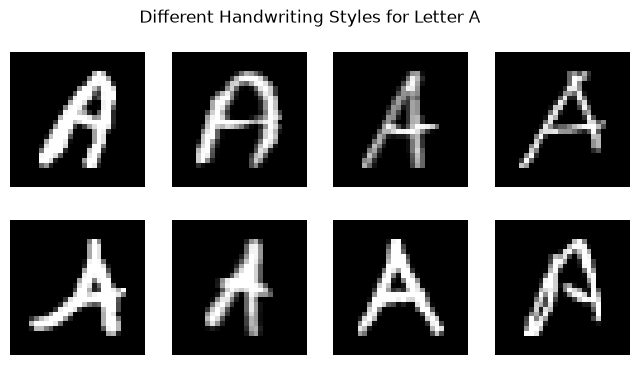

In [20]:
import matplotlib.pyplot as plt

a_samples = df[df.iloc[:,0] == 0].iloc[:8]

fig, axes = plt.subplots(2,4, figsize=(8,4))

for i, ax in enumerate(axes.flat):
    image = a_samples.iloc[i,1:].values.reshape(28,28)
    ax.imshow(image, cmap='gray')
    ax.axis('off')

plt.suptitle("Different Handwriting Styles for Letter A")
plt.show()

In [27]:
X = df.drop('output', axis=1)
y = df['output']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (372450, 784)
Labels shape: (372450,)


In [29]:
X = X / 255.0

In [30]:
print(X.min().min())
print(X.max().max())

0.0
1.0


In [31]:
X = X.values.reshape(-1, 28, 28, 1)

print(X.shape)

(372450, 28, 28, 1)


In [32]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=26)

print(y.shape)

(372450, 26)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

In [34]:
print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Images: (297960, 28, 28, 1)
Testing Images: (74490, 28, 28, 1)
Training Labels: (297960, 26)
Testing Labels: (74490, 26)


In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(X_train)

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([
    
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(26, activation='softmax')
])

In [38]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 395,418 (1.51 MB)

 Trainable params: 394,970 (1.51 MB)

 Non-trainable params: 448 (1.75 KB)

In [40]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=8,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/8
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 191s 40ms/step - accuracy: 0.9883 - loss: 0.0411 - val_accuracy: 0.9923 - val_loss: 0.0281
Epoch 2/8
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 174s 37ms/step - accuracy: 0.9883 - loss: 0.0409 - val_accuracy: 0.9926 - val_loss: 0.0276
Epoch 3/8
4656/4656 ━━━━━━━━━━━━━━━━━━━━ 165s 35ms/step - accuracy: 0.9882 - loss: 0.0409 - val_accuracy: 0.9918 - val_loss: 0.0341
Epoch 4/8
3067/4656 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.9887 - loss: 0.0390

In [43]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

2328/2328 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9925 - loss: 0.0279
Test Accuracy: 0.9924956560134888
Test Loss: 0.02785244584083557


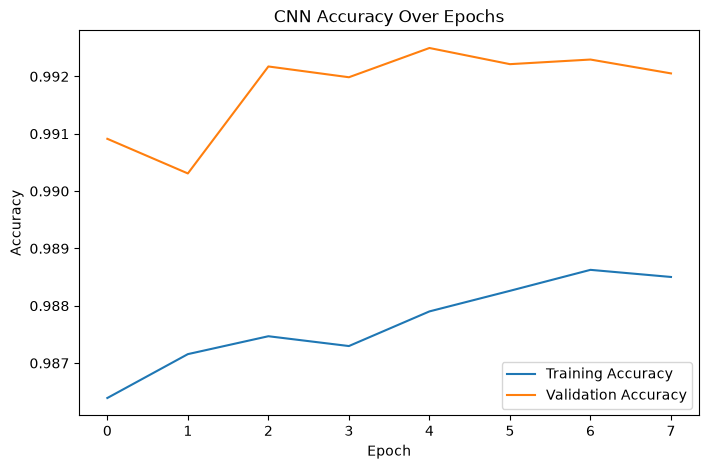

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

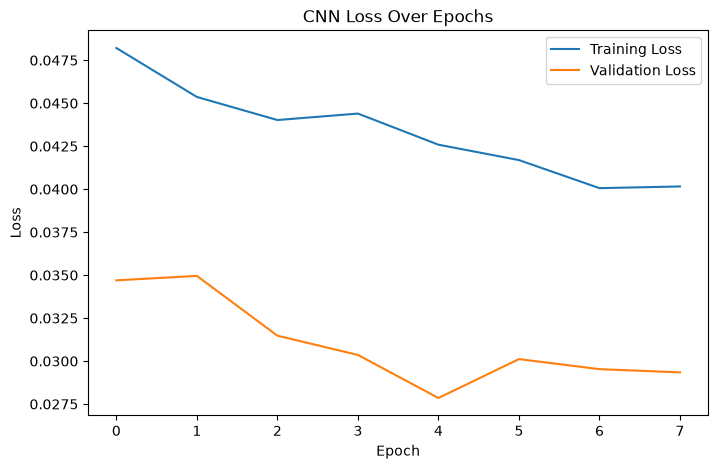

In [45]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [46]:
import numpy as np

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

2328/2328 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step


In [49]:
model.save("handwritten_alphabet_cnn.keras")

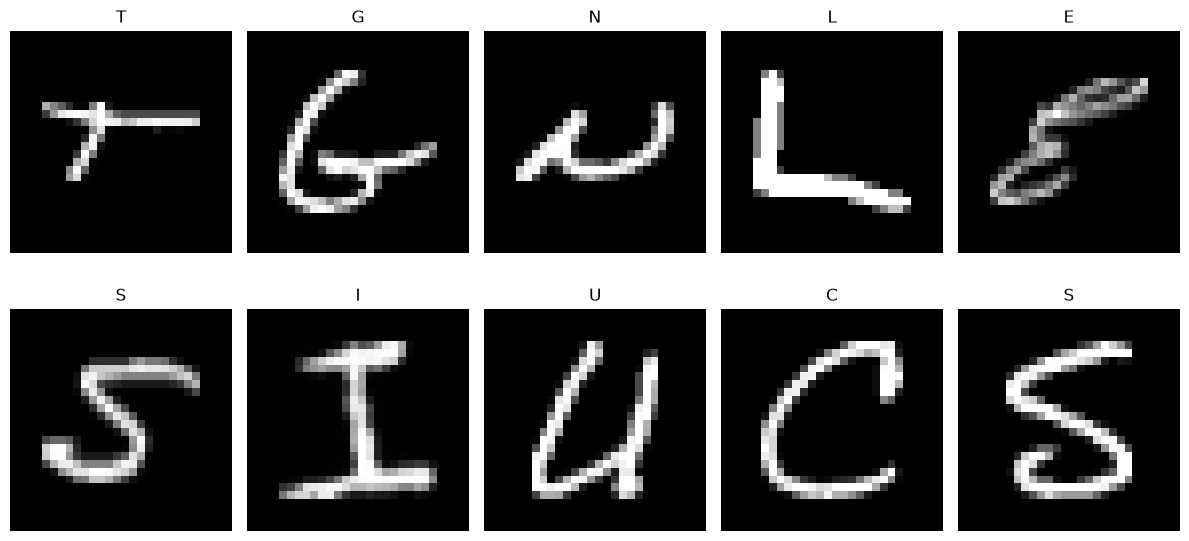

In [50]:
import random

plt.figure(figsize=(12,6))

for i in range(10):
    idx = random.randint(0, len(X_test)-1)

    image = X_test[idx]

    prediction = np.argmax(model.predict(image.reshape(1,28,28,1), verbose=0))

    plt.subplot(2,5,i+1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(chr(prediction + 65))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [52]:
from tensorflow.keras.models import load_model

model = load_model("handwritten_alphabet_cnn.keras")

In [54]:
from PIL import Image
import numpy as np

def preprocess_image(image_path):

    img = Image.open(image_path).convert('L')

    img = img.resize((28, 28))

    img_array = np.array(img)

    img_array = 255 - img_array

    img_array = img_array / 255.0

    img_array = img_array.reshape(1, 28, 28, 1)

    return img_array

In [55]:
word_dict = {
    0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',
    6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',
    12:'M',13:'N',14:'O',15:'P',16:'Q',
    17:'R',18:'S',19:'T',20:'U',21:'V',
    22:'W',23:'X',24:'Y',25:'Z'
}

In [58]:
import os

print(os.path.exists("../test images/A.png"))

True


In [59]:
from PIL import Image
import numpy as np

def preprocess_image(image_path):

    img = Image.open(image_path).convert('L')

    img = img.resize((28,28))

    img_array = np.array(img)

    img_array = 255 - img_array

    img_array = img_array / 255.0

    img_array = img_array.reshape(1,28,28,1)

    return img_array

In [60]:
from tensorflow.keras.models import load_model

model = load_model("handwritten_alphabet_cnn.keras")

In [62]:
img = preprocess_image("../test images/A.png")

prediction = model.predict(img)

predicted_class = np.argmax(prediction)

predicted_letter = chr(predicted_class + 65)

confidence = np.max(prediction)

print("Predicted Letter:", predicted_letter)
print("Confidence:", round(confidence*100,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Predicted Letter: A
Confidence: 100.0 %


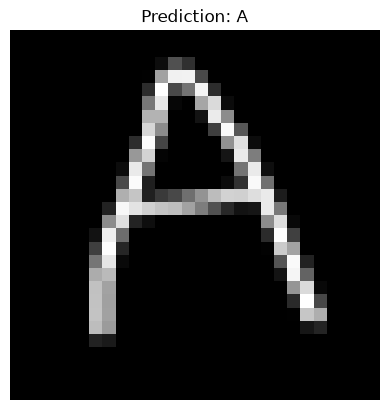

In [63]:
import matplotlib.pyplot as plt

plt.imshow(img.reshape(28,28), cmap='gray')
plt.title(f"Prediction: {predicted_letter}")
plt.axis('off')
plt.show()

In [64]:
import os

print(os.path.exists("../test images/P.png"))

True


In [65]:
from PIL import Image
import numpy as np

def preprocess_image(image_path):

    img = Image.open(image_path).convert('L')

    img = img.resize((28,28))

    img_array = np.array(img)

    img_array = 255 - img_array

    img_array = img_array / 255.0

    img_array = img_array.reshape(1,28,28,1)

    return img_array

In [67]:
img = preprocess_image("../test images/P.png")

prediction = model.predict(img)

predicted_class = np.argmax(prediction)

predicted_letter = chr(predicted_class + 65)

confidence = np.max(prediction)

print("Predicted Letter:", predicted_letter)
print("Confidence:", round(confidence*100,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Letter: P
Confidence: 100.0 %


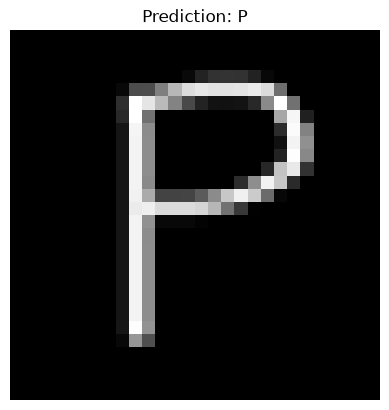

In [68]:
import matplotlib.pyplot as plt

plt.imshow(img.reshape(28,28), cmap='gray')
plt.title(f"Prediction: {predicted_letter}")
plt.axis('off')
plt.show()